

```
# author: puru panta (purupanta@uky.edu)
# date: 11/30/2024
# filename: PredictMLDL_Stacked
```



**STEP1: Install and Import libraries required**

In [7]:
!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn
!pip install xlsxwriter
!pip install --upgrade scikeras # Upgrade scikeras

  Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)


In [8]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, fbeta_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification

In [9]:
# Mounting google drive if it is already not mounted
def LoadGoogleDrive(googleDriveDir):
  # Link Google Drive
  import os
  # Check if Google Drive is already mounted
  if not os.path.exists(googleDriveDir + "/MyDrive"):
      print("Mounting Google Drive...")
      from google.colab import drive
      drive.mount(googleDriveDir)
  else:
      print("Google Drive is already mounted!")

**STEP2: Load google-drive, and data**

In [10]:
# Mount the google drive
googleDriveFolder = "/content/drive"
LoadGoogleDrive(googleDriveFolder)
# ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/ip_data/hints6_public.xlsx"
ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx"
ip_sheet_name = "hints6_public_cleaned" # "hints6_public_cleaned_diabetic" # "hints6_public"
colsToLoad = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes","MedConditions_HighBP", "MedConditions_HeartCondition","MedConditions_LungDisease", "MedConditions_Depression","AverageSleepNight","AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

print("Ip File Path: " + ip_file_path + "\t SheetName: " + ip_sheet_name)

# Loading cleaded excel data
df_orig = pd.read_excel(ip_file_path, sheet_name=ip_sheet_name, usecols=colsToLoad)
df = df_orig.copy()

predictors = df.drop(columns=['MedConditions_HeartCondition']).columns
target = df['MedConditions_HeartCondition'].name

print(f"df_orig.shape: {df_orig.shape}")

Google Drive is already mounted!
Ip File Path: /content/drive/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx	 SheetName: hints6_public_cleaned
df_orig.shape: (4875, 18)


**STEP3: Train-test split Scale, SMOTEENN**

In [11]:
def TrainTestSplit(df):
  from sklearn.model_selection import GridSearchCV, train_test_split

  # AllCols = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes", "MedConditions_HighBP", "MedConditions_HeartCondition", "MedConditions_LungDisease", "MedConditions_Depression", "AverageSleepNight", "AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

  # Define features (X) and target (y)
  X = df.drop(columns=['MedConditions_HeartCondition'])
  y = df['MedConditions_HeartCondition']

  # Convert categorical variables to numerical using one-hot encoding

  # Perform train-test split (80% train, 20% test)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )
  return X_train, X_test, y_train, y_test

# Step 2: Scale features using StandardScaler
def ScaleTrainData(X_train, X_test):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on training data
  X_test_scaled = scaler.transform(X_test)         # Use same scaler on test data
  return X_train_scaled, X_test_scaled, scaler

# Step 3: Apply SMOTE only to training data
def ApplySMOTE(X_train, y_train):
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print("Original shape:", y_train.shape)
    print("Resampled shape:", y_res.shape)
    return X_res, y_res

# Step 4: Apply ApplySMOTEENN only to training data
def ApplySMOTEENN(X_train, y_train):
  sm = SMOTEENN(random_state=42)
  X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

  print("Original dataset shape:", y_train.shape)
  print("Resampled dataset shape:", y_train_res.shape)
  return X_train_res, y_train_res

# Step 5: Apply ApplyADASYN only to training data
def ApplyADASYN(X_train, y_train):
  from imblearn.over_sampling import ADASYN
  adasyn = ADASYN(random_state=42)
  X_res, y_res = adasyn.fit_resample(X_train, y_train)
  print("Original training set shape:", y_train.shape)
  print("Resampled training set shape:", y_res.shape)
  return X_res, y_res

# Step 6: Apply ApplyBorderlineSMOTE only to training data
def ApplyBorderlineSMOTE(X_train, y_train, kind='borderline-1'):
  from imblearn.over_sampling import BorderlineSMOTE
  sm = BorderlineSMOTE(kind=kind, random_state=42)
  X_res, y_res = sm.fit_resample(X_train, y_train)
  print("Original shape:", y_train.shape)
  print("Resampled shape:", y_res.shape)
  return X_res, y_res

In [12]:
X_train, X_test, y_train, y_test = TrainTestSplit(df)

In [13]:
X_train_res, y_train_res = ApplySMOTEENN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyBorderlineSMOTE(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyADASYN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplySMOTE(X_train.copy(), y_train.copy())

Original dataset shape: (3900,)
Resampled dataset shape: (5510,)


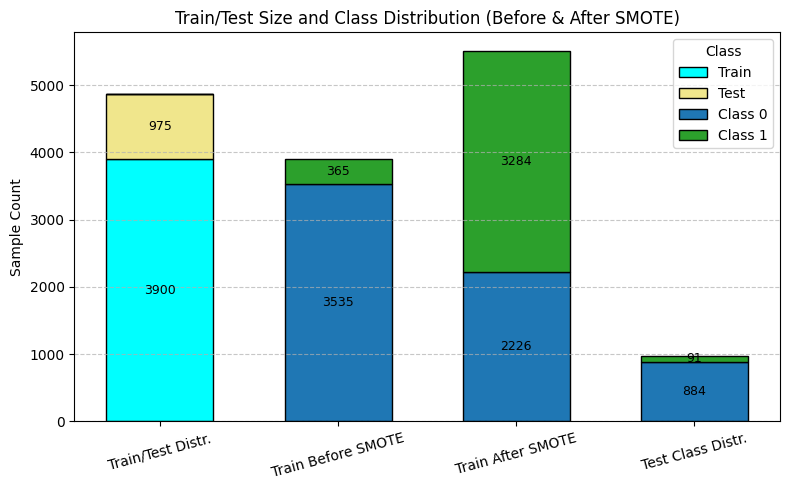

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_data = {
    'Train/Test Distr.': {
        'Train': len(y_train),
        'Test': len(y_test)
    },
    'Train Before SMOTE': {
        'Class 0': (y_train == 0).sum(),
        'Class 1': (y_train == 1).sum()
    },
    'Train After SMOTE': {
        'Class 0': (y_train_res == 0).sum(),
        'Class 1': (y_train_res == 1).sum()
    },
    'Test Class Distr.': {
        'Class 0': (y_test == 0).sum(),
        'Class 1': (y_test == 1).sum()
    }
}

# Define custom colors
class_colors = {
    'Class 0': '#1f77b4',  # blue
    'Class 1': '#2ca02c',  # green
    'Train': '#00FFFF',    # cyan
    'Test': '#F0E68C'      # dim yellow
}

# Convert to DataFrame
df_plot = pd.DataFrame(plot_data).T.fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_plot.index))
bar_width = 0.6
bottom = np.zeros(len(x))

# Plot each class/group
for cls in df_plot.columns:
    heights = df_plot[cls].values

    if np.all(heights == 0):
        continue  # Skip entire column if all zeros

    bars = ax.bar(
        x, heights, bottom=bottom, width=bar_width,
        label=cls, edgecolor='black', color=class_colors.get(cls, 'gray')
    )

    # Add number to each non-zero segment
    for i, height in enumerate(heights):
        if height > 0:
            ax.text(
                x[i], bottom[i] + height / 2, str(int(height)),
                ha='center', va='center', fontsize=9, color='black'
            )

    bottom += heights

# Axes and layout
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=15)
ax.set_title('Train/Test Size and Class Distribution (Before & After SMOTE)')
ax.set_ylabel('Sample Count')
ax.legend(title='Class', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
# Step 4: If needed, reshape the target arrays
y_train = y_train.to_numpy().ravel() if hasattr(y_train, 'to_numpy') else y_train.ravel()
y_test = y_test.to_numpy().ravel() if hasattr(y_test, 'to_numpy') else y_test.ravel()

In [16]:
# Train/Test assignments
X_train = X_train_res.copy();
y_train = y_train_res.copy();
X_test = X_test.copy();
y_test = y_test.copy();

In [17]:
X_train, X_test, scaler = ScaleTrainData(X_train.copy(), X_test.copy())

**STEP8: Prediction Starts**

In [18]:
import pandas as pd
import numpy as np
import time
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from collections import defaultdict

!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn

  Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)


**1. Stacking ensemble Model**

In [21]:
# Train/Test assignments
X_train_stacked = X_train.copy()
y_train_stacked = y_train.copy()
X_test_stacked = X_test.copy()
y_test_stacked = y_test.copy()

In [22]:
# STEP 1: Define Base Models as a list of tuples
base_models = [
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)),
    ('svm', SVC(kernel='poly', probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('gbm', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
]


Total execution time: 33.11 seconds
Stacked Model Accuracy: 0.80
Stacked Model Classification Report:
               precision    recall  f1-score   support

     Class 0       0.94      0.84      0.88       884
     Class 1       0.22      0.44      0.29        91

    accuracy                           0.80       975
   macro avg       0.58      0.64      0.59       975
weighted avg       0.87      0.80      0.83       975

Stacked Model AUC-ROC: 0.70


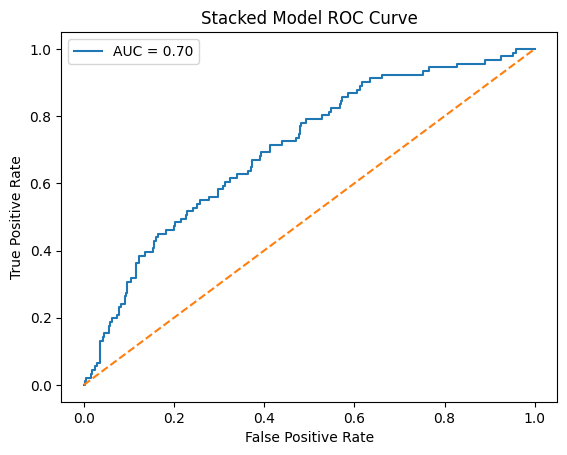

In [24]:
# Meta-model
meta_model = LogisticRegression(solver='liblinear', random_state=42)

stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=False,  # Exclude raw features in the meta-learner
    n_jobs=-1
)

# Start timing
start_time = time.time()

# Train the stacked model
stacked_model.fit(X_train_stacked, y_train_stacked)

# Predictions and evaluation
y_pred_stacked = stacked_model.predict(X_test_stacked)
y_prob_stacked = stacked_model.predict_proba(X_test_stacked)[:, 1]

# Stop timing
end_time = time.time()
# Calculate execution time
execution_time = end_time - start_time
print(f"Total execution time: {execution_time:.2f} seconds")

# Accuracy
accuracy_stacked = accuracy_score(y_test_stacked, y_pred_stacked)
print(f"Stacked Model Accuracy: {accuracy_stacked:.2f}")

# Classification report
target_names = ['Class 0', 'Class 1']
report_stacked = classification_report(y_test_stacked, y_pred_stacked, target_names=target_names)
print("Stacked Model Classification Report:\n", report_stacked)

# AUC-ROC
auc_roc_stacked = roc_auc_score(y_test, y_prob_stacked)
print(f"Stacked Model AUC-ROC: {auc_roc_stacked:.2f}")

# ROC Curve
fpr_stacked, tpr_stacked, thresholds_stacked = roc_curve(y_test, y_prob_stacked)
plt.plot(fpr_stacked, tpr_stacked, label=f'AUC = {auc_roc_stacked:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacked Model ROC Curve')
plt.legend()
plt.show()